#Deep Learning para visión de computadoras
##Lab 1.1 Introducción a visión por computadora


## Objetivos de aprendizaje

Al finalizar esta práctica, el estudiante será capaz de:

1. Configurar y verificar un entorno de trabajo en Google Colab con PyTorch, TorchVision y OpenCV.
2. Describir la representación digital de una imagen (píxeles, canales, resolución) y manipularla mediante operaciones básicas de lectura, color, geometría e intensidad.
3. Explorar el conjunto de datos CIFAR-10 con TorchVision: su estructura, sus clases y las características estadísticas de sus imágenes.

Activar GPU
`Entorno de ejecución → Cambiar tipo de entorno de ejecución → Acelerador de hardware → GPU (T4)`

In [ ]:
!nvidia-smi


Tue Sep  1 07:46:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#Librerías

In [ ]:
import importlib
import subprocess
import sys

paquetes = ["torch", "torchvision", "cv2", "matplotlib", "numpy", "PIL"]
nombres_pip = {"cv2": "opencv-python", "PIL": "pillow"}

for paquete in paquetes:
    try:
        mod = importlib.import_module(paquete)
        version = getattr(mod, "__version__", "instalado (sin atributo __version__)")
        print(f"[OK] {paquete}: {version}")
    except ImportError:
        nombre = nombres_pip.get(paquete, paquete)
        print(f"[INSTALANDO] {paquete} no encontrado, instalando {nombre} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", nombre])

[OK] torch: 2.11.0+cu128
[OK] torchvision: 0.26.0+cu128
[OK] cv2: 5.0.0
[OK] matplotlib: 3.10.0
[OK] numpy: 2.1.3
[OK] PIL: 11.3.0


In [ ]:
import torch
import torchvision
import cv2

print("PyTorch     :", torch.__version__)
print("TorchVision :", torchvision.__version__)
print("OpenCV      :", cv2.__version__)
print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch     : 2.11.0+cu128
TorchVision : 0.26.0+cu128
OpenCV      : 5.0.0
CUDA disponible: True
GPU: Tesla T4


`cv2_imshow` es una función propia de Google Colab para mostrar imágenes leídas con OpenCV (que por defecto están en formato BGR).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

plt.rcParams["figure.figsize"] = (6, 6)
print("Listo")

Listo


## Parte A. Manipulación de imágenes

In [ ]:
!pip install -q scikit-image


Tipo de dato   : <class 'numpy.ndarray'>
Forma (shape)  : (400, 600, 3)
Tipo de pixel  : uint8
Valor mínimo   : 0
Valor máximo   : 255


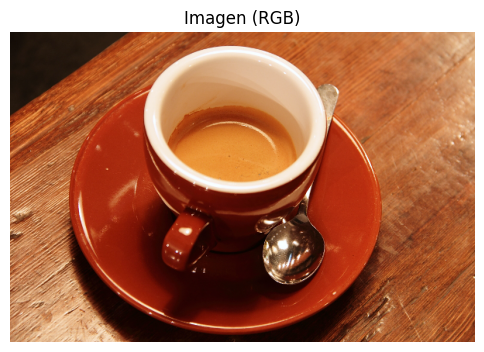

In [ ]:
from skimage import data

# Imagen ej en RGB, formato numpy (alto, ancho, canales)
imagen_rgb = data.coffee()

print("Tipo de dato   :", type(imagen_rgb))
print("Forma (shape)  :", imagen_rgb.shape)
print("Tipo de pixel  :", imagen_rgb.dtype)
print("Valor mínimo   :", imagen_rgb.min())
print("Valor máximo   :", imagen_rgb.max())

plt.imshow(imagen_rgb)
plt.title("Imagen (RGB)")
plt.axis("off")
plt.show()


**OpenCV vs. Matplotlib: el orden de canales BGR/RGB**

Formato OpenCV: (400, 600, 3)
Formato cv2_imshow (interpreta BGR correctamente):


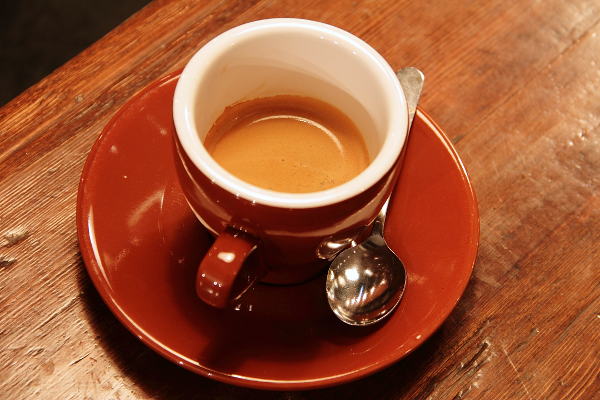

In [ ]:
import cv2
# a) Guarda imagen directamente
#cv2.imwrite("cafe.png", (imagen_rgb))

# b) Guardamos la imagen de skimage (RGB) a disco y la volvemos a leer con OpenCV
cv2.imwrite("cafe.png", cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2BGR))

imagen_bgr = cv2.imread("cafe.png")   # OpenCV siempre lee en BGR
print("Formato OpenCV:", imagen_bgr.shape)

# cv2_imshow interpreta el arreglo como BGR
print("Formato cv2_imshow (interpreta BGR correctamente):")
cv2_imshow(imagen_bgr)


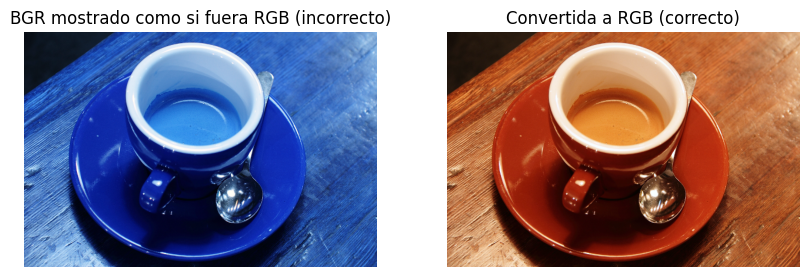

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(imagen_bgr)
ax[0].set_title("BGR mostrado como si fuera RGB (incorrecto)")
ax[0].axis("off")
#print("Formato OpenCV:", imagen_bgr.shape)

imagen_bgr_a_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
ax[1].imshow(imagen_bgr_a_rgb)
ax[1].set_title("Convertida a RGB (correcto)")
ax[1].axis("off")
plt.show()
#print("Formato OpenCV:", imagen_bgr_a_rgb.shape)


**Canales**

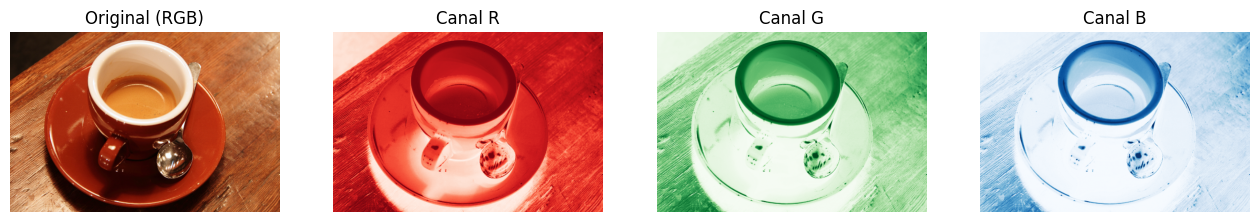

In [ ]:
R = imagen_rgb[:, :, 0]
G = imagen_rgb[:, :, 1]
B = imagen_rgb[:, :, 2]

fig, ax = plt.subplots(1, 4, figsize=(16, 5))
ax[0].imshow(imagen_rgb); ax[0].set_title("Original (RGB)"); ax[0].axis("off")
ax[1].imshow(R, cmap="Reds");   ax[1].set_title("Canal R"); ax[1].axis("off")
ax[2].imshow(G, cmap="Greens"); ax[2].set_title("Canal G"); ax[2].axis("off")
ax[3].imshow(B, cmap="Blues");  ax[3].set_title("Canal B"); ax[3].axis("off")
plt.show()

#print("Forma de cada canal:", R.shape)

**Escala de grises**

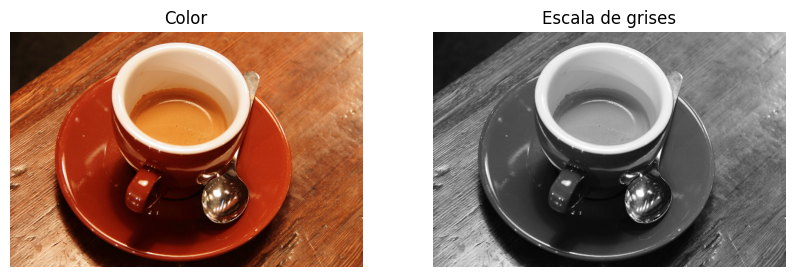

In [ ]:
imagen_gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(imagen_rgb); ax[0].set_title("Color"); ax[0].axis("off")
ax[1].imshow(imagen_gris, cmap="gray"); ax[1].set_title("Escala de grises"); ax[1].axis("off")
plt.show()

**Transformaciones geométricas**

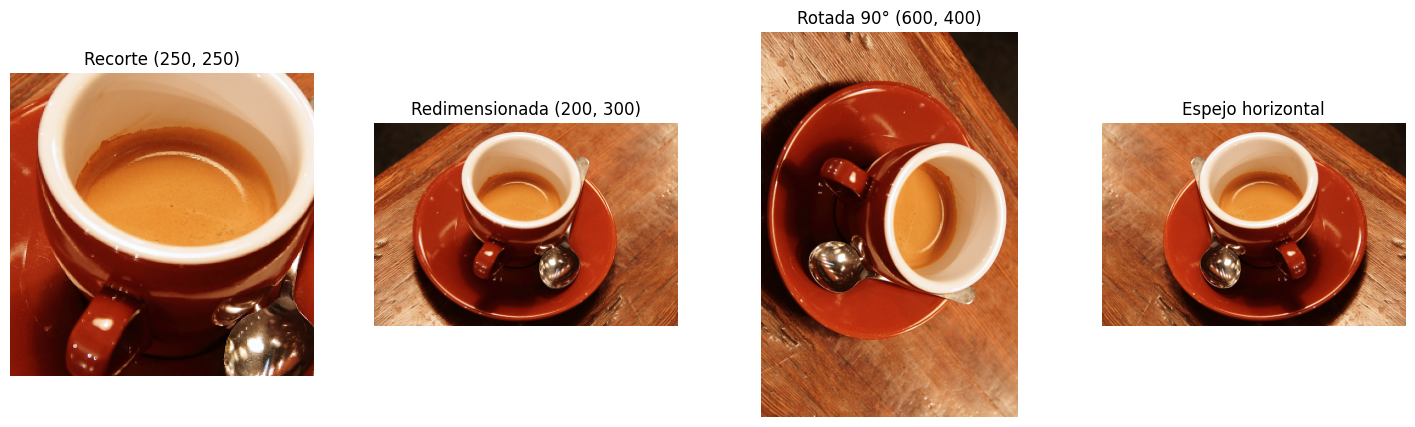

In [ ]:
alto, ancho = imagen_rgb.shape[:2]

# Recorte: seleccionar una región de interés (ROI)
recorte = imagen_rgb[50:300, 150:400]

# Redimensionamiento
redimensionada = cv2.resize(imagen_rgb, (ancho // 2, alto // 2))

# Rotación 90 grados
rotada = cv2.rotate(imagen_rgb, cv2.ROTATE_90_CLOCKWISE)

# Espejo horizontal (flip)
espejo = cv2.flip(imagen_rgb, 1)

fig, ax = plt.subplots(1, 4, figsize=(18, 5))
ax[0].imshow(recorte); ax[0].set_title(f"Recorte {recorte.shape[:2]}"); ax[0].axis("off")
ax[1].imshow(redimensionada); ax[1].set_title(f"Redimensionada {redimensionada.shape[:2]}"); ax[1].axis("off")
ax[2].imshow(rotada); ax[2].set_title(f"Rotada 90° {rotada.shape[:2]}"); ax[2].axis("off")
ax[3].imshow(espejo); ax[3].set_title("Espejo horizontal"); ax[3].axis("off")
plt.show()


**Brillo y contraste**
Simple operación aritmética **punto a punto** (no espacial):

$$ I_{salida}(x,y) = \alpha \cdot I_{entrada}(x,y) + \beta $$

donde $\alpha$ controla el contraste y $\beta$ controla el brillo

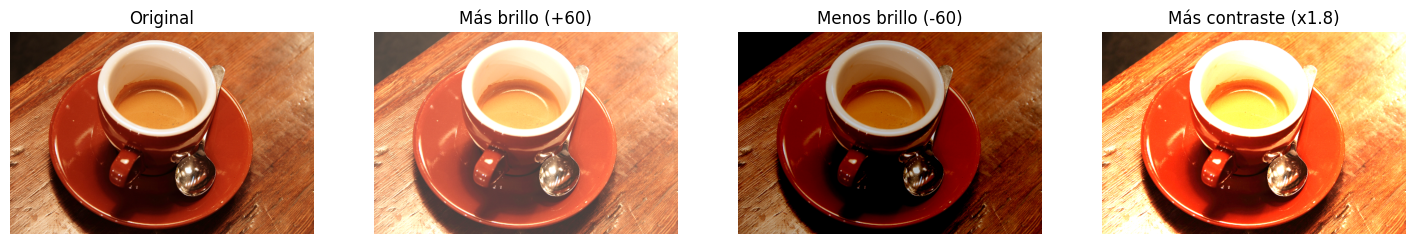

In [ ]:
def ajustar_brillo_contraste(img, alpha=1.0, beta=0):
    """alpha: contraste (1.0 = sin cambio) | beta: brillo (0 = sin cambio)"""
    ajustada = img.astype(np.float32) * alpha + beta
    ajustada = np.clip(ajustada, 0, 255).astype(np.uint8)
    return ajustada

mas_brillo   = ajustar_brillo_contraste(imagen_rgb, alpha=1.0, beta=60)
menos_brillo = ajustar_brillo_contraste(imagen_rgb, alpha=1.0, beta=-60)
mas_contraste = ajustar_brillo_contraste(imagen_rgb, alpha=1.8, beta=0)

fig, ax = plt.subplots(1, 4, figsize=(18, 5))
ax[0].imshow(imagen_rgb); ax[0].set_title("Original"); ax[0].axis("off")
ax[1].imshow(mas_brillo); ax[1].set_title("Más brillo (+60)"); ax[1].axis("off")
ax[2].imshow(menos_brillo); ax[2].set_title("Menos brillo (-60)"); ax[2].axis("off")
ax[3].imshow(mas_contraste); ax[3].set_title("Más contraste (x1.8)"); ax[3].axis("off")
plt.show()


**Histograma**
Muestra la distribución de valores de intensidad de una imagen; es una herramienta descriptiva.

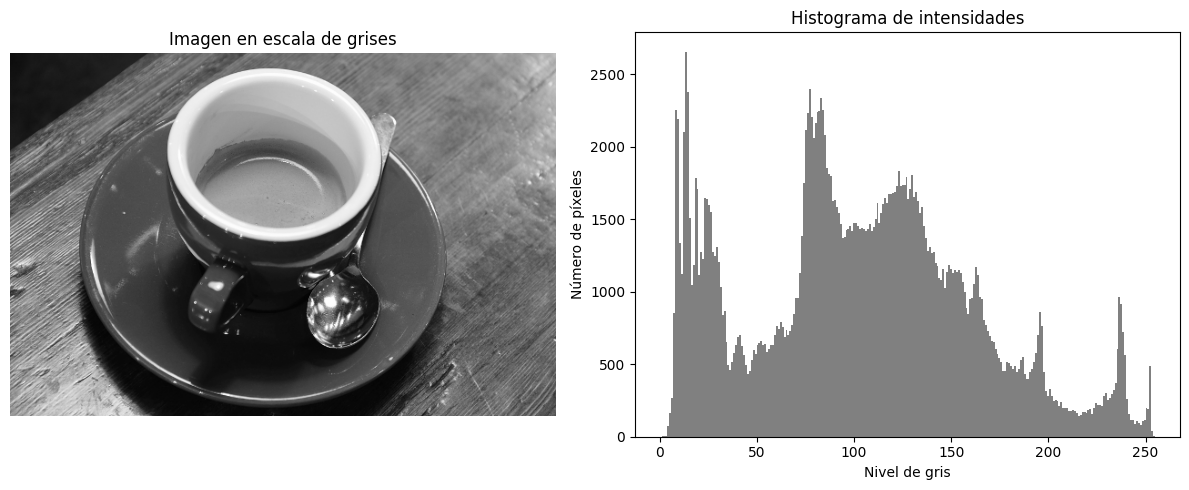

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(imagen_gris, cmap="gray")
ax[0].set_title("Imagen en escala de grises")
ax[0].axis("off")

ax[1].hist(imagen_gris.ravel(), bins=256, range=(0, 255), color="gray")
ax[1].set_title("Histograma de intensidades")
ax[1].set_xlabel("Nivel de gris")
ax[1].set_ylabel("Número de píxeles")
plt.tight_layout()
plt.show()

## Parte B. Datos CIFAR-10

Trabajaremos con el conjunto de datos CIFAR 10, podemos encontrar este conjunto de datos dentro de la API de keras, por lo que una forma de obtenerlo es:

from tensorflow import keras as K
(x_train, y_train),(x_test, y_test) = K.datasets.cifar10.load_data()

El conjunto de datos CIFAR-10 consta de 60000 imágenes de 32x32 colores (32, 32, 3) en 10 clases, con 6000 imágenes por clase. Hay 50000 imágenes de entrenamiento y 10000 imágenes de prueba.

El conjunto de datos se divide en cinco lotes de entrenamiento y un lote de prueba, cada uno con 10000 imágenes. El lote de prueba contiene exactamente 1000 imágenes seleccionadas al azar de cada clase. Los lotes de entrenamiento contienen las imágenes restantes en orden aleatorio, pero algunos lotes de entrenamiento pueden contener más imágenes de una clase que de otra. Entre ellos, los lotes de capacitación contienen exactamente 5000 imágenes de cada clase.

Las clases son completamente excluyentes entre sí. No hay superposición entre automóviles y camiones. “Automóvil” incluye sedanes, SUV, cosas por el estilo. “Camión” incluye solo camiones grandes. Tampoco incluye camionetas.
En conclusión, obtendremos 60000 imágenes y 60000 etiquetas.

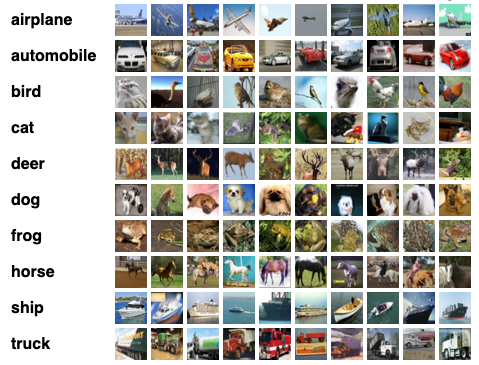

Documentación adicional : Explorar en artículos con código north_east

Página de inicio : https://www.cs.toronto.edu/~kriz/cifar.html

Código fuente : tfds.image_classification.Cifar10

Versiones :

3.0.2 (predeterminado): Sin notas de la versión.
Tamaño de descarga : 162.17 MiB

Tamaño del conjunto de datos : 132.40 MiB

Almacenamiento en caché automático ( documentación ): Sí

Divisiones :

Dividir	Ejemplos
'test'	10.000
'train'	50.000
Estructura de características :

FeaturesDict({
    'id': Text(shape=(), dtype=string),
    'image': Image(shape=(32, 32, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
})

https://www.kaggle.com/datasets/ghnshymsaini/cifar-10-image-dataset


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Definir transformación básica para convertir la imagen a Tensor PyTorch (C, H, W) valores [0 1]
transform = transforms.Compose([
    transforms.ToTensor()
])

print("Descargando dataset CIFAR-10...")
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

classes = ('Avión', 'Automóvil', 'Pájaro', 'Gato', 'Ciervo',
           'Perro', 'Rana', 'Caballo', 'Barco', 'Camión')



**Ejercicio: Estructura del dataset**

In [ ]:
print("Tipo de dato       :" )
print("Forma del tensor    :")
print("Rango de valores    :")
print("Etiqueta (índice)   :")
print("Etiqueta (clase)    :")

**Extraer exactamente 1 imagen representativa por cada clase**

In [ ]:
images_per_class = {}
for image, label in trainset:
    if label not in images_per_class:
        images_per_class[label] = image
    if len(images_per_class) == 10:
        break


**Visualizar las 10 imágenes en una cuadrícula de 2x5**

In [ ]:

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("CIFAR-10: Muestra de 1 Imagen por Clase", fontsize=16, fontweight='bold')

for label_idx in range(10):
    row = label_idx // 5
    col = label_idx % 5

    # En PyTorch el formato es (Canales, Altura, Ancho) -> Transponemos a (Altura, Ancho, Canales) para Matplotlib
    img_tensor = images_per_class[label_idx]
    img_np = img_tensor.permute(1, 2, 0).numpy()

    axes[row, col].imshow(img_np)
    axes[row, col].set_title(f"Clase {label_idx}: {classes[label_idx]}")
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print(f"Dimensiones de cada imagen: {img_tensor.shape} (Canales x Alto x Ancho)")

**Ejercicio: Separación de canales, conversión a escala de grises e histograma de 4 imagenes**

**Ejercicio: Elige una imagen de CIFAR-10 y aplica tres combinaciones distintas de $\alpha$ y $\beta$ (ver sección 1.6). Muestra los resultados en una sola figura y comenta qué combinación conserva mejor los detalles.**